# Practical 2
## A Graph Neural Network Model for Node Classification
### (and how to build it from scratch)

### Overview
In this practical, you will implement the base graph neural network model from scratch (without using PyTorch Geometric), and prepare it for node classification. You will train your model for node classification on Cora dataset, which is an academic citation network. The task is to predict the category of each paper (which corresponds to a node in the citation network) among the seven available. We introduced the base graph neural network model in the course (Lectures 6), as an instance of message passing neural networks, and studied a particular parameterization of this model (Lecture 7).

For each part and task, answer the given questions and complete the code where missing (this is indicated by the `pass` keyword).

## Part 0: Installing dependencies
Despite the fact we will not use PyTorch Geometric to build the GNN, we will use it to handle the Cora dataset, as it is included in the base distribution.
Follow the given instructions to set up your Colab notebook correctly.

First of all, we advice you to enable GPU acceleration for your notebook. This can be done by navigating to `Runtime > Change runtime type > Hardware accelerator (GPU) > Save`. You may getting an error explaining that no GPUs are currently available. This is fine, you don't really need them for this practical, however they'll make your computations significantly faster.

Some other tips & tricks:
- press `Shift + Enter` to run a cell and move to the next one (`Ctrl + Enter` to only run it)
- when you execute a cell, the variables you create are saved into a global namespace. As a consequence, changes in the code will not take effect until you re-run that specific cell.
- remember to save your notebook every once in a while!

In [1]:
# Check PyTorch version installed on this system
!python -c "import torch; print(torch.__version__)"

1.13.0+cu116


In [2]:
%%capture
# Download the corresponding PyTorch Geometric module
"""
Assign to TORCH with what you get from the cell above. E.g., export TORCH=1.12.1+cu113
"""
%env TORCH=1.13.0+cu116
!pip install torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install torch-geometric

## Part 1: Building a GNN
In this part, you will build a GNN using PyTorch, aiming to emulate the PyTorch Geometric modules. You will construct your neural network using PyTorch nn modules, and build training and testing helper functions to train and evaluate your model.

### Task 1.1
Understand the base structure of a PyTorch neural network model, namely `torch.nn.Module`, and build your GNN as a class with its own instantiation of `__init__` and `forward`. You will define GNN components within `__init__`, and construct the GNN data flow in `forward`. We recommend that you construct your model such that the number of layers is parametrized. That is, you can increase or decrease the number of layers simply by changing the range of an inner loop that creates the needed layers.

Furthermore, as a node classification GNN is composed by a sequence of Graph Convolution Layers and by a Multi Layer Perceptron head used to classify each node, we suggest to define a separate module for each of these components, and then aggregate them together in the final model.

In [3]:
# Let's first import all the things we are gonna need for this task

import torch
import torch.nn as nn
import numpy as np
import torch.nn.functional as F
# torch_geometric only used to load the Cora dataset
from torch_geometric.datasets import Planetoid
from torch_geometric.loader import DataLoader
import torch_geometric.utils as U

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("gpu")

dataset = Planetoid("/tmp/Cora", name="Cora")
num_nodes = dataset.data.num_nodes
num_edges = dataset.data.num_edges // 2
num_features = dataset.num_node_features
num_classes = dataset.num_classes

Processing...
Done!


Please complete the following classes, adding the respective `__init__` and `forward` methods.  
Please construct your model such that the number of layers is parametrized. That is, you can increase or decrease the number of layers simply by changing the range of an inner loop that creates the needed layers. In general, try to hard-code the least amount of behaviour inside your network. Prefer, instead, the use of parameters passed during initialization, as it will come in handy later on (e.g., you can chosse to hard code the activation functions used for each model but also leave them as a model parameter).

A `GNNLayer` computes the operations seen in the lectures, that is:

$ h_i^{(t+1)} = \sigma(W^{(t)}_{self} h_i^{(t)} + W^{(t)}_{neigh} \sum_{j \in neigh(i)} h_j^{(t)})$.

Remember that PyTorch is realy efficient in parallelizing computations by vectorizing them. In other words, you don't need to (you must not!) loop over all the neighbours of each node to compute the summation in the above equation. Use instead matrix operations.

In [ ]:
class GNNLayer(nn.Module):
    
    def __init__(self, input_dim, output_dim, act_fn):
        super(GNNLayer, self).__init__()
        self.self_aggregate = nn.Linear(input_dim, output_dim)
        self.neighbour_aggregate = nn.Linear(input_dim, output_dim)
        self.act_fn = act_fn

    def forward(self, node_feats, adj_matrix):
        # action of adj_matrix on node_feats is to sum the features of each node's neighbour

        # aggregate, then apply non linearity
        return self.act_fn(self.self_aggregate(node_feats) + self.neighbour_aggregate(adj_matrix @ node_feats))


The `GNNModule` is a collection of GNNLayers. In PyTorch you can create a list of layers by using `nn.ModuleList(layer_1, layer_2, ...)` or, equivalentely `nn.ModuleList(*layer_list)`. Remember activation functions!

In [ ]:
class GNNModule(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim, 
                 num_layers, act_fn=nn.ReLU):
        super(GNNModule, self).__init__()
        if num_layers >= 2:
            modules = [GNNLayer(input_dim, hidden_dim, act_fn)]


            for i in range(num_layers - 2):
                modules += [GNNLayer(hidden_dim, hidden_dim, act_fn)]

            modules += [GNNLayer(hidden_dim, output_dim, act_fn)]
        elif num_layers == 1:
            modules = [GNNLayer(input_dim, output_dim, act_fn)]
        else:
            modules = []

        self.net = nn.ModuleList(modules)

    def forward(self, x, adj_matrix):
        for m in self.net:
            x = m(x, adj_matrix)
        return x

The `MLPModule` is a classification head that you apply to each node in the input graph after applying the gnn layers. It is a collection of `nn.Linear` layers.

In [ ]:
class MLPModule(nn.Module):
    
    def __init__(self, input_dim, hidden_dim, output_dim, 
                 num_layers, act_fn=nn.ReLU):
        super(MLPModule, self).__init__()
        if num_layers >= 2:
            modules = [nn.Linear(input_dim, hidden_dim), act_fn]


            for i in range(num_layers - 2):
                modules += [nn.Linear(hidden_dim, hidden_dim), act_fn]

            modules += [nn.Linear(hidden_dim, output_dim), act_fn]
        elif num_layers == 1:
            modules = [nn.Linear(input_dim, output_dim), act_fn]
        else:
            modules = []

        self.net = nn.ModuleList(modules)

    def forward(self, x):
        for m in self.net:
            x = m(x)
        return x

Let's aggregate everything in a single class:

In [ ]:
class CoraNodeClassification(nn.Module):

    def __init__(self, num_features, num_classes,
                 gnn=True, mlp=True,
                 gnn_hidden_dim=1, mlp_hidden_dim=1,
                 gnn_num_layers=1, mlp_num_layers=1, 
                 gnn_act_fn=nn.ReLU(), 
                 mlp_act_fn=nn.ReLU()):
        super(CoraNodeClassification, self).__init__()
    
        input_dim = num_features 
        output_dim = num_classes

        self.gnn = gnn 
        self.mlp = mlp
        
        self.gnn_module = GNNModule(input_dim, gnn_hidden_dim, gnn_hidden_dim,
                                    gnn_num_layers, act_fn=gnn_act_fn)
        
        # perhaps could add non-linearity here as well?
        self.interm_module = nn.Linear(gnn_hidden_dim, mlp_hidden_dim)
        
        if self.gnn:
            self.mlp_module = MLPModule(mlp_hidden_dim, mlp_hidden_dim, output_dim, 
                                        mlp_num_layers, act_fn=mlp_act_fn)
        else:
            self.mlp_module = MLPModule(input_dim, mlp_hidden_dim, output_dim, 
                                        mlp_num_layers, act_fn=mlp_act_fn)
       

    def forward(self, x, adj_matrix):
        if self.gnn:
            x = self.gnn_module(x, adj_matrix)
        if self.gnn and self.mlp:
            x = self.interm_module(x)
        if self.mlp:
            x = self.mlp_module(x)
        return x

  
    # Used to reset the weights of the network when training multiple times with
    # different hyperparameters
    def reset_parameters(self):
        def _reset_module_parameters(module):
            for layer in module.children():
                if hasattr(layer, 'reset_parameters'):
                    layer.reset_parameters()
                elif hasattr(layer, 'children'):
                    for child_layer in layer.children():
                        _reset_module_parameters(child_layer)

        _reset_module_parameters(self)

### Task 1.2
Create dedicated functions for training and testing. For training, your functions should return a vector containing the train loss and accuracy after each epoch (since Cora contains a single graph one epoch corresponds to one training iteration). You can also print out those values while the training it's running. However, given the large number of epochs, we advise you print every 8 steps or so. Your test function should return the final accuracy on the test set. If everything works correctly you should get around ~75% accuracy.

Cora uses a masking approach to divide between the train and test set. Therefore, to compute the loss/accuracy, mask out the part of your output based on the current settings, e.g., `loss = model.loss_fn(y[data.train_mask], data.y[data.train_mask])`

In [ ]:
# The Cora dataset contains a single graph of 2708 nodes (i.e., papers).
# We will use some of the nodes as training set and some as test set.
data = dataset[0].to(device)

# According to the GNN equations, we need the adjacency matrix to compute each
# layer convolution. The following line convert the sparse data
# (i.e., list of edges) stored in the dataset in a single dense matrix.
adj_matrix = U.to_dense_adj(data.edge_index).squeeze(0)

# Define the hyperparameters we are gonna use:
params = {
    "gnn_hidden_features": 128,
    "mlp_hidden_features": 80,
    "num_gnn_layers": 2,
    "num_mlp_layers": 2,
    "learning_rate": 1e-4,
    "weight_decay": 0,
    "num_epochs": 1500,
}

# Remember to move the model to the correct device using `.to(device)`
# The arguments to be passed to the class CoraNodeClassification __init__ functions
# depends on how you defined the method. This is an example.
model = CoraNodeClassification(num_features, num_classes,
                               gnn=True, mlp=True,
                               gnn_hidden_dim=params["gnn_hidden_features"],
                               mlp_hidden_dim=params["mlp_hidden_features"],
                               gnn_num_layers=params["num_gnn_layers"],
                               mlp_num_layers=params["num_mlp_layers"], 
                               gnn_act_fn=nn.ReLU(), 
                               mlp_act_fn=nn.ReLU()
                              ).to(device)

In [ ]:
def accuracy(pred, target):
    return (pred == target).float().mean().item()

In [ ]:
def test(model, data, adj_matrix, params):
    # Put model into evaluation mode
    model.eval()

    mask = data.test_mask

    # find most likely label from the predicted output
    pred = model(data.x, adj_matrix).argmax(dim=1)[mask]

    # true label
    target = data.y[mask]


    test_accuracy = accuracy(pred, target)

    return test_accuracy


# By testing a random initialized module you should get around ~15% accuracy
test(model, data, adj_matrix, params)

0.07900000363588333

In [ ]:
def train(model, data, adj_matrix, params):
    # use cross entropy for classification
    criterion = torch.nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(model.parameters(), 
                                 lr=params["learning_rate"],
                                 weight_decay=params["weight_decay"])

    mask = data.train_mask
    x = data.x
    target = data.y[mask]
    


    for epoch in range(params["num_epochs"]):
        # set model to train mode
        model.train()

        # compute predicted logits and labels
        pred_logits = model(x, adj_matrix)[mask]
        pred = pred_logits.argmax(dim=1)

        loss = criterion(pred_logits, target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_accuracy = accuracy(pred, target)

        if epoch % 100 == 0:
            print("loss: {}, acc: {}".format(loss, train_accuracy))

        losses.append(loss)
        train_accuracies.append(train_accuracy)
        test_accuracies.append(test(model, data, adj_matrix, params))


    return losses, train_accuracies, test_accuracies


train_losses, train_accuracies, _ = train(model, data, adj_matrix, params)
# Now you shold get around ~75-77%!
test_accuracy = test(model, data, adj_matrix, params)
print("Final test accuracy:", test_accuracy)

loss: 1.948020100593567, acc: 0.12142857164144516
loss: 0.6612654328346252, acc: 0.8571428656578064
loss: 0.31325894594192505, acc: 0.8571428656578064
loss: 0.28583383560180664, acc: 0.8571428656578064
loss: 0.28091543912887573, acc: 0.8571428656578064
loss: 0.2794875204563141, acc: 0.8571428656578064
loss: 0.27894464135169983, acc: 0.8571428656578064
loss: 0.2790810167789459, acc: 0.8571428656578064
loss: 0.2784627377986908, acc: 0.8571428656578064
loss: 0.27833473682403564, acc: 0.8571428656578064
loss: 0.2782592475414276, acc: 0.8571428656578064
loss: 0.27822068333625793, acc: 0.8571428656578064
loss: 0.27816706895828247, acc: 0.8571428656578064
loss: 0.27813491225242615, acc: 0.8571428656578064
loss: 0.27811112999916077, acc: 0.8571428656578064
Final test accuracy: 0.7240000367164612


#### Task 1.2.1
Can you modify the training function to return the test accuracy at every step as well?
By plotting the train accuracy and test accuracy over time, what can you observe?


loss: 1.9606643915176392, acc: 0.12857143580913544
loss: 0.704390823841095, acc: 0.7428571581840515
loss: 0.05680309608578682, acc: 1.0
loss: 0.009570893831551075, acc: 1.0
loss: 0.0037673809565603733, acc: 1.0
loss: 0.0020345551893115044, acc: 1.0
loss: 0.0012815091758966446, acc: 1.0
loss: 0.0008840892114676535, acc: 1.0
loss: 0.0006474130204878747, acc: 1.0
loss: 0.0004943064996041358, acc: 1.0


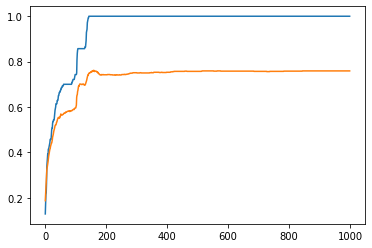

Final test accuracy: 0.7590000629425049


In [ ]:
params = {
    "gnn_hidden_features": 128,
    "mlp_hidden_features": 128,
    "num_gnn_layers": 2,
    "num_mlp_layers": 1,
    "learning_rate": 1e-4,
    "weight_decay": 0,
    "num_epochs": 1000,
}
model = CoraNodeClassification(num_features, num_classes,
                               gnn=True, mlp=True,
                               gnn_hidden_dim=params["gnn_hidden_features"],
                               mlp_hidden_dim=params["mlp_hidden_features"],
                               gnn_num_layers=params["num_gnn_layers"],
                               mlp_num_layers=params["num_mlp_layers"], 
                               gnn_act_fn=nn.ReLU(), 
                               mlp_act_fn=nn.ReLU()
                              ).to(device)

train_losses, train_accuracies, test_accuracies = train(model, data, adj_matrix, params)

import matplotlib.pyplot as plt
plt.plot(train_accuracies)
plt.plot(test_accuracies)
plt.show()

print("Final test accuracy:", test_accuracies[-1])
# best result: 2 gnn layers, one mlp layer, test-cc: 0.764

## Part 2: Ablation Studies (Optional)

### 2.1: Importance of GNN and MLP modules
Add a parameter to the `CoraNodeClassification` class that allows you to select which modules to enable: only GNN, only MLP, or both. For example, your `forward` should look similarly to the following:

```python
def forward(self, x, adj_matrix):
    if self.gnn is not None:
      x = self.gnn(x, adj_matrix)
    
    if self.mlp is not None:
      x = self.mlp(x)

    return x
```

What is the impact of the two modules on the final result? Play a little around `hidden_features` and `num_layers` and briefly describe what you observe.

loss: 17027.88671875, acc: 0.0
loss: 54.27947998046875, acc: 0.44999998807907104
loss: 11.972140312194824, acc: 0.5142857432365417
loss: 4.630337715148926, acc: 0.6928571462631226
loss: 1.890263557434082, acc: 0.7285714149475098
loss: 2.092698335647583, acc: 0.7428571581840515
loss: 3.8190813064575195, acc: 0.7571428418159485
loss: 52.6942138671875, acc: 0.37857142090797424
loss: 4.4084601402282715, acc: 0.3928571343421936
loss: 3.6603457927703857, acc: 0.41428571939468384


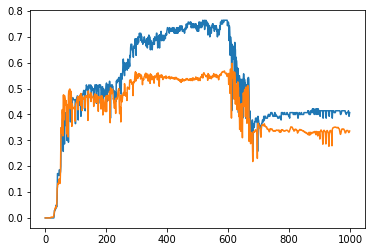

Final test accuracy: 0.3360000252723694


In [ ]:
# GNN ONLY
train_params = {
    "learning_rate": 1e-4,
    "weight_decay": 0,
    "num_epochs": 1000,
}
gnn_model = CoraNodeClassification(num_features, num_classes,
                                   gnn=True, mlp=False,
                                   gnn_hidden_dim=128,
                                   gnn_num_layers=8,
                                   gnn_act_fn=nn.ReLU(), 
                                  ).to(device)

train_losses, train_accuracies, test_accuracies = train(gnn_model, data, 
                                                        adj_matrix, train_params)

import matplotlib.pyplot as plt
plt.plot(train_accuracies)
plt.plot(test_accuracies)
plt.show()

print("Final test accuracy:", test_accuracies[-1])
# some results:
# layers |train acc | test acc
#   8    |    0.97  |   0.58 <---- over smoothing!
#   3    |    1     |   0.74
#   2    |    1     |   0.74
#   1    |    1     |   0.69


# So with 2 GNN layers the network already manages to capture the graph quite well
# Adding more will cause oversmoothing, so perhaps it's better from that point on
# to go on with classic MLP's

loss: 1.9467095136642456, acc: 0.1428571492433548
loss: 1.894308090209961, acc: 0.4214285612106323
loss: 0.8551150560379028, acc: 0.5714285969734192
loss: 0.8359936475753784, acc: 0.5714285969734192
loss: 0.8346865177154541, acc: 0.5714285969734192
loss: 0.8342902064323425, acc: 0.5714285969734192
loss: 0.8341468572616577, acc: 0.5714285969734192
loss: 0.8340691328048706, acc: 0.5714285969734192
loss: 0.8340520858764648, acc: 0.5714285969734192
loss: 0.8340222239494324, acc: 0.5714285969734192


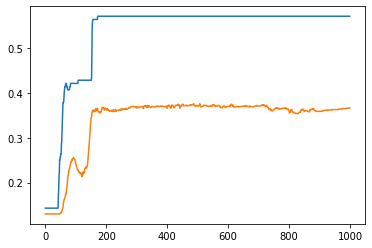

Final test accuracy: 0.367000013589859


In [ ]:
# MLP ONLY
train_params = {
    "learning_rate": 1e-4,
    "weight_decay": 1e-6,
    "num_epochs": 1000,
}
mlp_model = CoraNodeClassification(num_features, num_classes,
                                   gnn=False, mlp=True,
                                   mlp_hidden_dim=128,
                                   mlp_num_layers=8,
                                   mlp_act_fn=nn.ReLU(), 
                                  ).to(device)

train_losses, train_accuracies, test_accuracies = train(mlp_model, data, 
                                                        adj_matrix, train_params)

import matplotlib.pyplot as plt
plt.plot(train_accuracies)
plt.plot(test_accuracies)
plt.show()

print("Final test accuracy:", test_accuracies[-1])

# some results:
# layers |train acc | test acc
#   8    |    0.57  |   0.21 
#   3    |    0.42  |   0.23 <---- probably needs more time to train properly
#   2    |    0.71  |   0.45
#   1    |    0.96  |   0.45 <---- overfitting

# Hence, without message passing the network is not capable of generalizing from
# the data even if it manages to memorize the training data



### 2.2: Importance of non-linearities
Try to replace all your activation functions with identities (or simply remove them). Do the results change? What does this tell you about this specific problem?

loss: 1.9782754182815552, acc: 0.12142857164144516
loss: 0.1846095323562622, acc: 1.0
loss: 0.02327379211783409, acc: 1.0
loss: 0.006658479105681181, acc: 1.0
loss: 0.003139717038720846, acc: 1.0
loss: 0.0018418803811073303, acc: 1.0
loss: 0.001215369557030499, acc: 1.0
loss: 0.000863061985000968, acc: 1.0
loss: 0.0006444496684707701, acc: 1.0
loss: 0.0004991106688976288, acc: 1.0


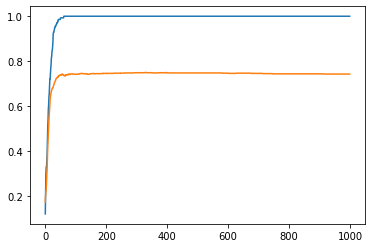

Final test accuracy: 0.7430000305175781


In [ ]:
params = {
    "gnn_hidden_features": 128,
    "mlp_hidden_features": 128,
    "num_gnn_layers": 2,
    "num_mlp_layers": 1,
    "learning_rate": 1e-4,
    "weight_decay": 0,
    "num_epochs": 1000,
}

# REMOVE NON LINEARITIES
linear_model = CoraNodeClassification(num_features, num_classes,
                                      gnn=True, mlp=True,
                                      gnn_hidden_dim=params["gnn_hidden_features"],
                                      mlp_hidden_dim=params["mlp_hidden_features"],
                                      gnn_num_layers=params["num_gnn_layers"],
                                      mlp_num_layers=params["num_mlp_layers"], 
                                      gnn_act_fn=nn.Identity(), 
                                      mlp_act_fn=nn.Identity()
                                     ).to(device)

train_losses, train_accuracies, test_accuracies = train(linear_model, data, 
                                                        adj_matrix, params)

import matplotlib.pyplot as plt
plt.plot(train_accuracies)
plt.plot(test_accuracies)
plt.show()

print("Final test accuracy:", test_accuracies[-1])

# RESULTS DON'T CHANGE! 

# hence the problem is linear w.r.t overall graph data
# (but the node features aren't independent, otherwise MLP would train as well as GNN)